# ***1. IMPORT LIBRARIES***

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from imblearn.over_sampling import SMOTE

# Classification Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Unsupervised Learning (K-Means)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_auc_score,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_curve, auc, ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


# ***2. LOAD & INSPECT DATA***

In [2]:
# Load dataset
df = pd.read_csv('retail_store_sales.csv')

print("Dataset loaded successfully!")
print(f"\nDataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")


Dataset loaded successfully!

Dataset Shape: (12575, 11)
Total Rows: 12575, Total Columns: 11


In [3]:
# Display first few rows
print("\n--- First 5 Rows ---")
print(df.head())

# Display column information
print("\n--- Column Information ---")
print(df.info())

# Check for missing values

print("\n--- Missing Values Analysis ---")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing_values,
    'Missing_Percent': missing_percent
})
print(missing_df[missing_df['Missing_Count'] > 0])

# Check for duplicates
duplicate_rows = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicate_rows}")


--- First 5 Rows ---
  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3         

# ***3. DATA CLEANING & PREPROCESSING***

In [4]:
print("DATA PREPROCESSING")
print("="*60)

# Create a copy for processing
df_clean = df.copy()

print("Data copied for processing.")

DATA PREPROCESSING
Data copied for processing.


### 3.1 Handle missing values

In [5]:
print("\n1. Handling Missing Values...")

# Fill numerical columns with median

numerical_cols = df_clean.select_dtypes(include='number')
for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Fill categorical 'Item' with mode or 'Unknown'
df_clean['Item'] = df_clean['Item'].str.lstrip("Item_")
df_clean['Item'] = df_clean['Item'].str.rstrip("_PAT")
df_clean['Item'] = df_clean['Item'].str.rstrip("_MILK")
df_clean['Item'] = df_clean['Item'].str.rstrip("_BUT")
df_clean['Item'] = df_clean['Item'].str.rstrip("_FOOD")
df_clean['Item'] = df_clean['Item'].str.rstrip("_BEV")
df_clean['Item'] = df_clean['Item'].str.rstrip("_FUR")
df_clean['Item'] = df_clean['Item'].str.rstrip("_EHE")
df_clean['Item'] = df_clean['Item'].str.rstrip("_CEA")
df_clean['Item'].fillna(0, inplace=True)
df_clean['Item'] = df_clean['Item'].astype(int)

print("Missing values handled successfully!")


1. Handling Missing Values...
Missing values handled successfully!


C:\Users\Araf\AppData\Local\Temp\ipykernel_16500\2290719156.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
C:\Users\Araf\AppData\Local\Temp\ipykernel_16500\2290719156.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


### 3.2 Drop irrelevant columns


In [6]:
print("\n2. Dropping Irrelevant Columns...")
columns_to_drop = ['Transaction ID', 'Customer ID', 'Transaction Date']
df_clean = df_clean.drop(columns=columns_to_drop, errors='ignore')
print(f"Dropped columns: {columns_to_drop}")



2. Dropping Irrelevant Columns...
Dropped columns: ['Transaction ID', 'Customer ID', 'Transaction Date']


### 3.3 Convert Discount Applied to binary


In [7]:
print("\n3. Encoding Target Variable...")


df_clean['Discount Applied'] = df_clean['Discount Applied'].replace({True: 1, False: 0})
df_clean['Discount Applied'] = df_clean['Discount Applied'].fillna(0)

# Check class distribution
print("Discount Applied distribution:")
class_counts = df_clean['Discount Applied'].value_counts()
print(class_counts)

# Safely calculate class ratio
if 1 in class_counts and class_counts[1] > 0:
    class_ratio = class_counts[0] / class_counts[1]
    print(f"Class ratio (No:Yes): {class_ratio:.2f}:1")
else:
    print("Class ratio (No:Yes): Only 'No Discount' instances found or 'Yes' count is zero.")


3. Encoding Target Variable...
Discount Applied distribution:
Discount Applied
0.0    8356
1.0    4219
Name: count, dtype: int64
Class ratio (No:Yes): 1.98:1


C:\Users\Araf\AppData\Local\Temp\ipykernel_16500\352775176.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['Discount Applied'] = df_clean['Discount Applied'].replace({True: 1, False: 0})


### 3.4 Label Encode categorical variables


In [8]:
print("\n4. Encoding Categorical Variables (Label Encoding)...")
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns to encode: {categorical_cols}")

df_encoded = df_clean.copy() # Start with a copy for encoding

if categorical_cols:
    label_encoder = LabelEncoder()
    for col in categorical_cols:
        df_encoded[col] = label_encoder.fit_transform(df_encoded[col])
    print(f"After encoding: {df_encoded.shape[1]} columns. (Label Encoded)")
else:
    print("No categorical columns to encode")


4. Encoding Categorical Variables (Label Encoding)...
Categorical columns to encode: ['Category', 'Payment Method', 'Location']
After encoding: 8 columns. (Label Encoded)


### 3.5 Define features and targets

In [9]:
print("\n5. Defining Features and Targets...")

# Classification target
y_class = df_encoded['Discount Applied'].astype(int)

# Regression target
y_reg = df_encoded['Total Spent']

# Features (drop target columns and related features to avoid data leakage)
X = df_encoded.drop(['Discount Applied', 'Total Spent'], axis=1, errors='ignore')

print(f"Features shape: {X.shape}")
print(f"Classification target shape: {y_class.shape}")
print(f"Regression target shape: {y_reg.shape}")


5. Defining Features and Targets...
Features shape: (12575, 6)
Classification target shape: (12575,)
Regression target shape: (12575,)


### 3.6 Train-Test Split

In [10]:
print("\n6. Splitting Data...")

# For classification (stratified split for imbalanced data)
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

# For regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"Classification - Train: {X_train_class.shape}, Test: {X_test_class.shape}")
print(f"Regression - Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")


6. Splitting Data...
Classification - Train: (10060, 6), Test: (2515, 6)
Regression - Train: (10060, 6), Test: (2515, 6)


### 3.7 Feature Scaling


In [11]:
print("\n7. Scaling Features...")

scaler = StandardScaler()

# Scale classification data
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled = scaler.transform(X_test_class)

# Scale regression data
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

print("Feature scaling completed!")

# Convert back to DataFrame for readability
X_train_class_scaled_df = pd.DataFrame(X_train_class_scaled, columns=X.columns)
X_test_class_scaled_df = pd.DataFrame(X_test_class_scaled, columns=X.columns)
X_train_reg_scaled_df = pd.DataFrame(X_train_reg_scaled, columns=X.columns)
X_test_reg_scaled_df = pd.DataFrame(X_test_reg_scaled, columns=X.columns)



7. Scaling Features...
Feature scaling completed!


### 3.8 Handle Class Imbalance with SMOTE

In [12]:
print("\n8. Handling Class Imbalance...")
print(f"Before SMOTE - Class distribution in training set: {np.bincount(y_train_class)}")

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_class_scaled, y_train_class)

print(f"After SMOTE - Class distribution: {np.bincount(y_train_balanced)}")
print("Class imbalance handled successfully!")


8. Handling Class Imbalance...
Before SMOTE - Class distribution in training set: [6685 3375]
After SMOTE - Class distribution: [6685 6685]
Class imbalance handled successfully!


# ***4. EXPLORATORY DATA ANALYSIS (EDA)***

### 4.1 Correlation Analysis

EXPLORATORY DATA ANALYSIS

1. Correlation Analysis...


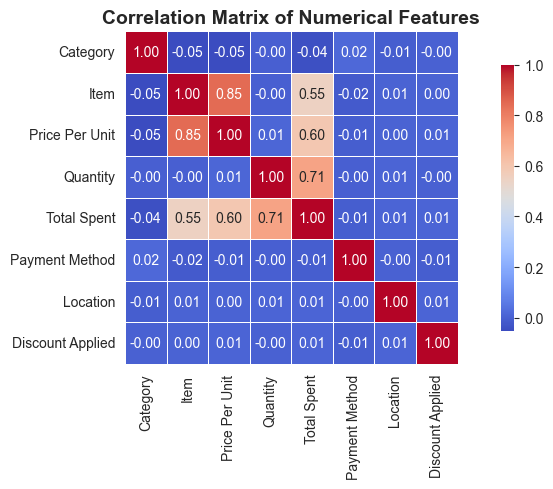


Correlation Matrix:
                  Category      Item  Price Per Unit  Quantity  Total Spent  \
Category          1.000000 -0.050233       -0.051831 -0.004027    -0.041319   
Item             -0.050233  1.000000        0.845585 -0.002952     0.548398   
Price Per Unit   -0.051831  0.845585        1.000000  0.011306     0.597021   
Quantity         -0.004027 -0.002952        0.011306  1.000000     0.709033   
Total Spent      -0.041319  0.548398        0.597021  0.709033     1.000000   
Payment Method    0.015062 -0.015769       -0.009503 -0.003625    -0.009968   
Location         -0.009164  0.005131        0.004782  0.007260     0.008722   
Discount Applied -0.001419  0.004438        0.008115 -0.000781     0.006234   

                  Payment Method  Location  Discount Applied  
Category                0.015062 -0.009164         -0.001419  
Item                   -0.015769  0.005131          0.004438  
Price Per Unit         -0.009503  0.004782          0.008115  
Quantity       

In [13]:

print("EXPLORATORY DATA ANALYSIS")
print("="*60)

### 4.1 Correlation Analysis
print("\n1. Correlation Analysis...")

# Calculate correlation matrix
corr_matrix = df_encoded.corr()

plt.figure(figsize=(9, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
print(corr_matrix)

### 4.2 Target Distribution


2. Target Variable Distribution...


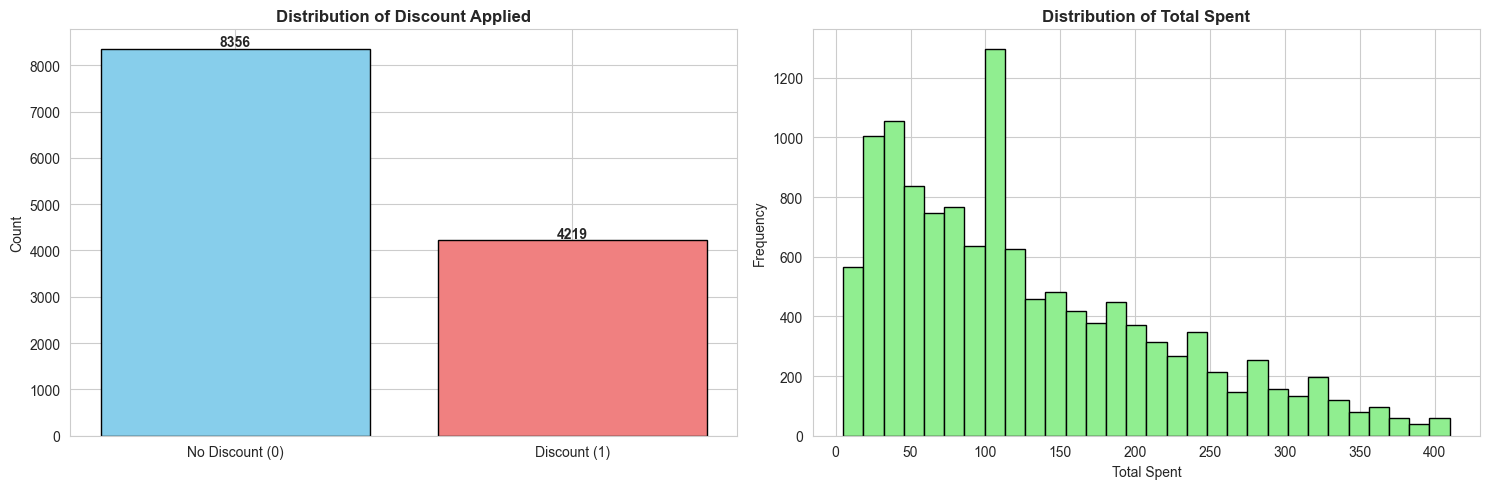

In [14]:
### 4.2 Target Distribution
print("\n2. Target Variable Distribution...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Classification target
axes[0].bar(['No Discount (0)', 'Discount (1)'],
            df_clean['Discount Applied'].value_counts().values,
            color=['skyblue', 'lightcoral'], edgecolor='black')
axes[0].set_title('Distribution of Discount Applied', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(df_clean['Discount Applied'].value_counts().values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Regression target distribution
axes[1].hist(df_clean['Total Spent'], bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title('Distribution of Total Spent', fontweight='bold')
axes[1].set_xlabel('Total Spent')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 4.3 Feature Relationships


3. Feature Relationships...


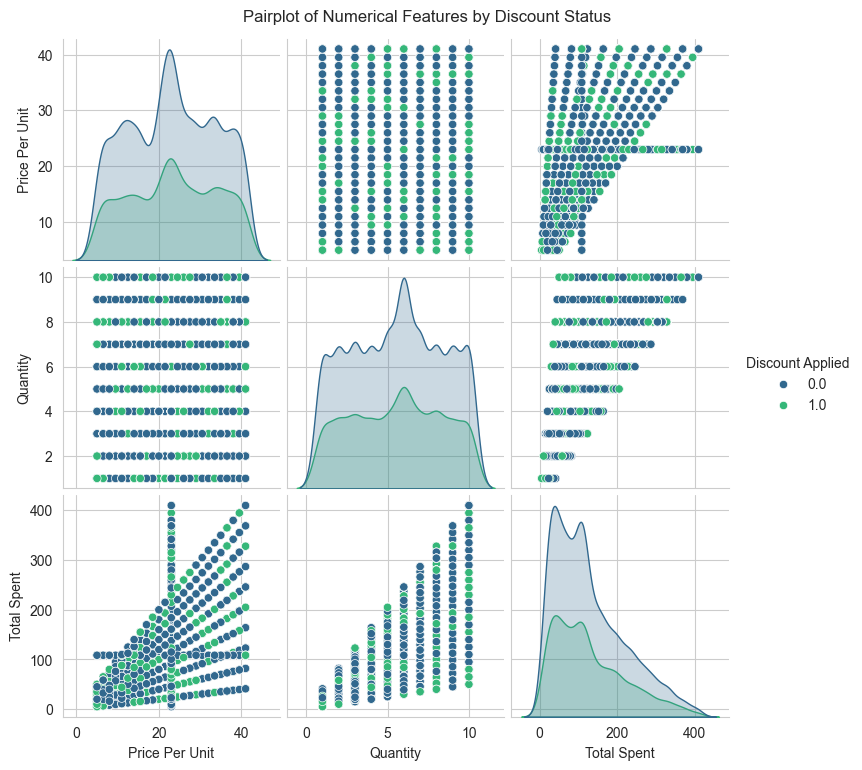

In [15]:
### 4.3 Feature Relationships
print("\n3. Feature Relationships...")

# Pairplot of numerical features
numerical_subset = df_clean[['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']]
sns.pairplot(numerical_subset, hue='Discount Applied', palette='viridis', diag_kind='kde')
plt.suptitle('Pairplot of Numerical Features by Discount Status', y=1.02)
plt.show()

# ***5. CLASSIFICATION MODELS***

### 5.1 K-Nearest Neighbors (KNN)

In [42]:
print("CLASSIFICATION MODELS TRAINING")
print("="*60)

# Dictionary to store model results
classification_results = {}

### 5.1 K-Nearest Neighbors (KNN)
print("\n1. Training K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_balanced, y_train_balanced)

y_train_pred_knn = knn_model.predict(X_train_balanced)
y_test_pred_knn = knn_model.predict(X_test_class_scaled)
y_test_pred_knn_proba = knn_model.predict_proba(X_test_class_scaled)[:, 1]

knn_train_acc = accuracy_score(y_train_balanced, y_train_pred_knn)
knn_test_acc = accuracy_score(y_test_class, y_test_pred_knn)
knn_precision = precision_score(y_test_class, y_test_pred_knn)
knn_recall = recall_score(y_test_class, y_test_pred_knn)
knn_auc = roc_auc_score(y_test_class, y_test_pred_knn_proba)

classification_results['KNN'] = {
    'Train_Acc': knn_train_acc,
    'Test_Acc': knn_test_acc,
    'Precision': knn_precision,
    'Recall': knn_recall,
    'AUC': knn_auc,
    'Probabilities': y_test_pred_knn_proba,
    'Model': knn_model
}

print(f"KNN Test Accuracy: {knn_test_acc:.4f}")
print(f"KNN Precision: {knn_precision:.4f}")

print(f"KNN Recall: {knn_recall:.4f}")
print(f"KNN AUC Score: {knn_auc:.4f}")

CLASSIFICATION MODELS TRAINING

1. Training K-Nearest Neighbors...
KNN Test Accuracy: 0.5161
KNN Precision: 0.3303
KNN Recall: 0.4301
KNN AUC Score: 0.4923


### 5.2 Logistic Regression

In [43]:
### 5.2 Logistic Regression
print("\n2. Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_balanced, y_train_balanced)

y_train_pred_lr = lr_model.predict(X_train_balanced)
y_test_pred_lr = lr_model.predict(X_test_class_scaled)
y_test_pred_lr_proba = lr_model.predict_proba(X_test_class_scaled)[:, 1]

lr_train_acc = accuracy_score(y_train_balanced, y_train_pred_lr)
lr_test_acc = accuracy_score(y_test_class, y_test_pred_lr)
lr_precision = precision_score(y_test_class, y_test_pred_lr)
lr_recall = recall_score(y_test_class, y_test_pred_lr)
lr_auc = roc_auc_score(y_test_class, y_test_pred_lr_proba)

classification_results['Logistic Regression'] = {
    'Train_Acc': lr_train_acc,
    'Test_Acc': lr_test_acc,
    'Precision': lr_precision,
    'Recall': lr_recall,
    'AUC': lr_auc,
    'Probabilities': y_test_pred_lr_proba,
    'Model': lr_model
}

print(f"Logistic Regression Test Accuracy: {lr_test_acc:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")

print(f"Logistic Regression Recall: {lr_recall:.4f}")
print(f"Logistic Regression AUC Score: {lr_auc:.4f}")


2. Training Logistic Regression...
Logistic Regression Test Accuracy: 0.5002
Logistic Regression Precision: 0.3331
Logistic Regression Recall: 0.4882
Logistic Regression AUC Score: 0.4851


### 5.3 Neural Network (MLP)

In [44]:
### 5.3 Neural Network (MLP)
print("\n3. Training Neural Network (MLP)...")
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp_model.fit(X_train_balanced, y_train_balanced)

y_train_pred_mlp = mlp_model.predict(X_train_balanced)
y_test_pred_mlp = mlp_model.predict(X_test_class_scaled)
y_test_pred_mlp_proba = mlp_model.predict_proba(X_test_class_scaled)[:, 1]

mlp_train_acc = accuracy_score(y_train_balanced, y_train_pred_mlp)
mlp_test_acc = accuracy_score(y_test_class, y_test_pred_mlp)
mlp_precision = precision_score(y_test_class, y_test_pred_mlp)
mlp_recall = recall_score(y_test_class, y_test_pred_mlp)
mlp_auc = roc_auc_score(y_test_class, y_test_pred_mlp_proba)

classification_results['Neural Network'] = {
    'Train_Acc': mlp_train_acc,
    'Test_Acc': mlp_test_acc,
    'Precision': mlp_precision,
    'Recall': mlp_recall,
    'AUC': mlp_auc,
    'Probabilities': y_test_pred_mlp_proba,
    'Model': mlp_model
}

print(f"Neural Network Test Accuracy: {mlp_test_acc:.4f}")
print(f"Neural Network Precision: {mlp_precision:.4f}")

print(f"Neural Network Recall: {mlp_recall:.4f}")
print(f"Neural Network AUC Score: {mlp_auc:.4f}")


3. Training Neural Network (MLP)...
Neural Network Test Accuracy: 0.4859
Neural Network Precision: 0.3167
Neural Network Recall: 0.4597
Neural Network AUC Score: 0.4725


### 5.4 Decision Tree

In [45]:
### 5.4 Decision Tree (Additional model)
print("\n4. Training Decision Tree...")
dt_model = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    class_weight='balanced'
)
dt_model.fit(X_train_balanced, y_train_balanced)

y_train_pred_dt = dt_model.predict(X_train_balanced)
y_test_pred_dt = dt_model.predict(X_test_class_scaled)
y_test_pred_dt_proba = dt_model.predict_proba(X_test_class_scaled)[:, 1]

dt_train_acc = accuracy_score(y_train_balanced, y_train_pred_dt)
dt_test_acc = accuracy_score(y_test_class, y_test_pred_dt)
dt_precision = precision_score(y_test_class, y_test_pred_dt)
dt_recall = recall_score(y_test_class, y_test_pred_dt)
dt_auc = roc_auc_score(y_test_class, y_test_pred_dt_proba)

classification_results['Decision Tree'] = {
    'Train_Acc': dt_train_acc,
    'Test_Acc': dt_test_acc,
    'Precision': dt_precision,
    'Recall': dt_recall,
    'AUC': dt_auc,
    'Probabilities': y_test_pred_dt_proba,
    'Model': dt_model
}

print(f"Decision Tree Test Accuracy: {dt_test_acc:.4f}")
print(f"Decision Tree Precision: {dt_precision:.4f}")
print(f"Decision Tree Recall: {dt_recall:.4f}")

print(f"Decision Tree AUC Score: {dt_auc:.4f}")


4. Training Decision Tree...
Decision Tree Test Accuracy: 0.6362
Decision Tree Precision: 0.3394
Decision Tree Recall: 0.0889
Decision Tree AUC Score: 0.4943


# ***6. K-MEANS CLUSTERING (UNSUPERVISED)***

### 6.1 Prepare data for clustering (use scaled classification features)

In [46]:
print("K-MEANS CLUSTERING (UNSUPERVISED LEARNING)")
print("="*60)

### 6.1 Prepare data for clustering (use scaled classification features)
print("\n1. Preparing Data for Clustering...")
clustering_data = X_train_class_scaled


K-MEANS CLUSTERING (UNSUPERVISED LEARNING)

1. Preparing Data for Clustering...


### 6.2 Determine optimal number of clusters


2. Determining Optimal Number of Clusters...


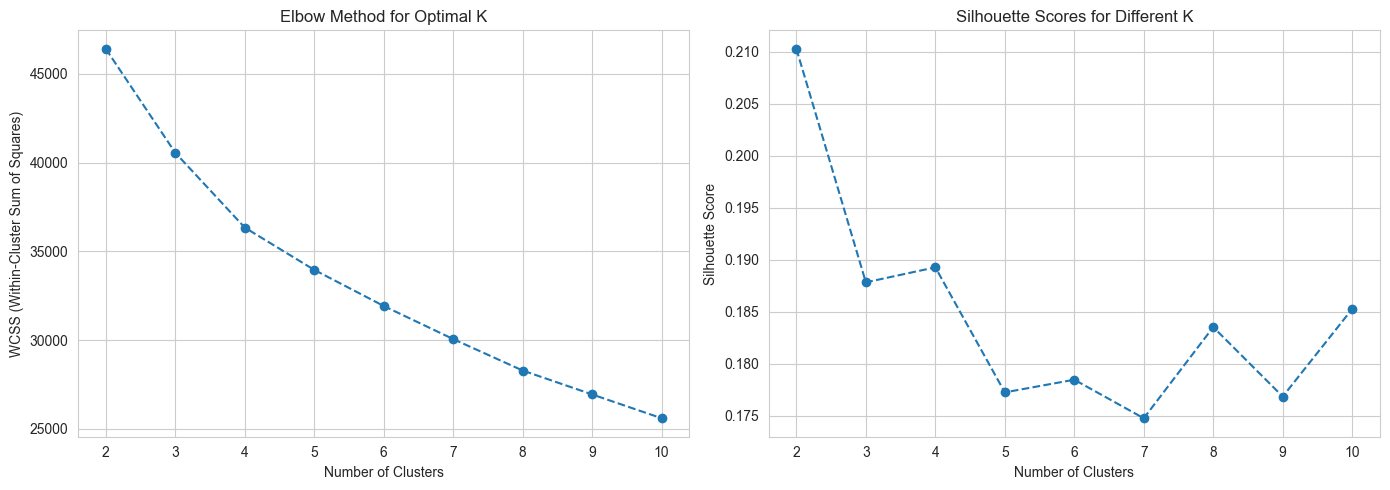

Optimal number of clusters (based on silhouette score): 2


In [47]:
print("\n2. Determining Optimal Number of Clusters...")
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(clustering_data)
    wcss.append(kmeans.inertia_)

    if k > 1:  # Silhouette score needs at least 2 clusters
        silhouette_scores.append(silhouette_score(clustering_data, kmeans.labels_))

# Plot elbow method and silhouette scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Method
axes[0].plot(k_range, wcss, marker='o', linestyle='--')
axes[0].set_title('Elbow Method for Optimal K')
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('WCSS (Within-Cluster Sum of Squares)')
axes[0].grid(True)

# Silhouette Scores
axes[1].plot(k_range, silhouette_scores, marker='o', linestyle='--')
axes[1].set_title('Silhouette Scores for Different K')
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Choose optimal k (max silhouette score)
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters (based on silhouette score): {optimal_k}")

### 6.3 Apply K-Means with optimal k

In [48]:
### 6.3 Apply K-Means with optimal k
print(f"\n3. Applying K-Means with k = {optimal_k}...")
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(clustering_data)

# Add cluster labels to training data
X_train_clustered = X_train_class_scaled_df.copy()
X_train_clustered['Cluster'] = cluster_labels


3. Applying K-Means with k = 2...


### 6.4 Visualize clusters with PCA


5. Visualizing Clusters with PCA...


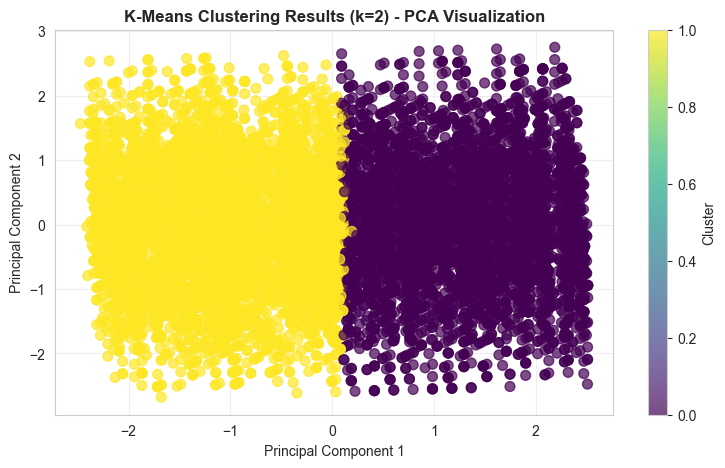

Explained variance by PC1 and PC2: 47.91%


In [49]:
### 6.5 Visualize clusters with PCA
print("\n5. Visualizing Clusters with PCA...")
pca = PCA(n_components=2)
clustering_data_2d = pca.fit_transform(clustering_data)

plt.figure(figsize=(9, 5))
scatter = plt.scatter(clustering_data_2d[:, 0], clustering_data_2d[:, 1],
                      c=cluster_labels, cmap='viridis', alpha=0.7, s=50)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clustering Results (k={optimal_k}) - PCA Visualization', fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained variance by PC1 and PC2: {pca.explained_variance_ratio_.sum():.2%}")

### 6.5 Analyze cluster characteristics


6. Cluster Characteristics Analysis...

Cluster Centroids (mean values):
         Category      Item  Price Per Unit  Quantity  Payment Method  \
Cluster                                                                 
0       -0.084060  0.944218        0.883128  0.001725       -0.023440   
1        0.069442 -0.780021       -0.729555 -0.001425        0.019364   

         Location  
Cluster            
0        0.014901  
1       -0.012310  


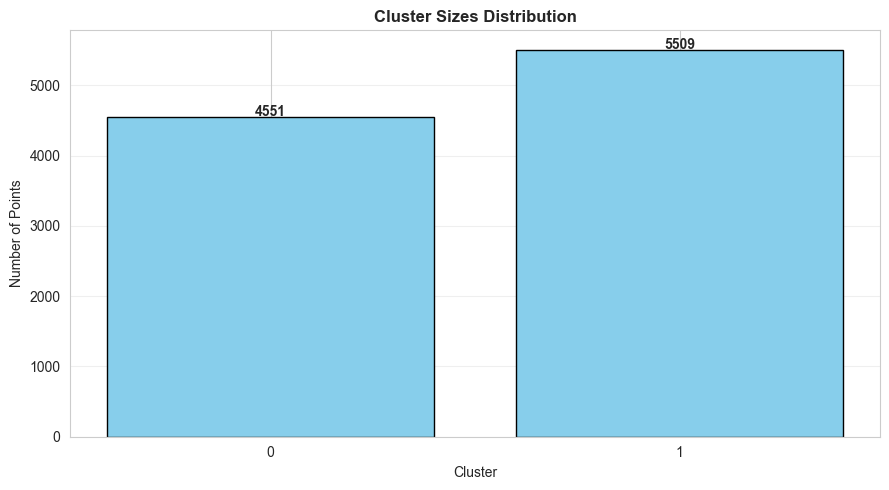

In [50]:
### 6.6 Analyze cluster characteristics
print("\n6. Cluster Characteristics Analysis...")

# Create a DataFrame with original features and cluster labels
cluster_analysis_df = pd.DataFrame(clustering_data, columns=X.columns)
cluster_analysis_df['Cluster'] = cluster_labels

# Calculate mean values for each cluster
cluster_means = cluster_analysis_df.groupby('Cluster').mean()

print("\nCluster Centroids (mean values):")
print(cluster_means.head())

# Visualize cluster characteristics
plt.figure(figsize=(9, 5))
cluster_sizes = X_train_clustered['Cluster'].value_counts().sort_index()
plt.bar(cluster_sizes.index.astype(str), cluster_sizes.values, color='skyblue', edgecolor='black')
plt.title('Cluster Sizes Distribution', fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Points')
plt.grid(axis='y', alpha=0.3)

# Add count labels
for i, count in enumerate(cluster_sizes.values):
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ***7. MODEL COMPARISON & EVALUATION***

 ● Precision, Recall comparison

 ● Confusion Matrix

 ● AUC score, ROC curve

### 7.1 Create comparison DataFrame

In [51]:

print("MODEL COMPARISON & EVALUATION")
print("="*60)

comparison_df = pd.DataFrame({
    'Model': list(classification_results.keys()),
    'Train_Accuracy': [results['Train_Acc'] for results in classification_results.values()],
    'Test_Accuracy': [results['Test_Acc'] for results in classification_results.values()],
    'Precision': [results['Precision'] for results in classification_results.values()],
    'Recall': [results['Recall'] for results in classification_results.values()],
    'AUC_Score': [results['AUC'] for results in classification_results.values()]
})

# Calculate overfitting indicator
comparison_df['Overfit_Gap'] = comparison_df['Train_Accuracy'] - comparison_df['Test_Accuracy']

# Sort by Test Accuracy
comparison_df = comparison_df.sort_values('Test_Accuracy', ascending=False)

print("\nModel Performance Comparison:")
print(comparison_df.to_string(index=False))

MODEL COMPARISON & EVALUATION

Model Performance Comparison:
              Model  Train_Accuracy  Test_Accuracy  Precision   Recall  AUC_Score  Overfit_Gap
      Decision Tree        0.595138       0.636183   0.339367 0.088863   0.494344    -0.041045
                KNN        0.765221       0.516103   0.330300 0.430095   0.492328     0.249117
Logistic Regression        0.508676       0.500199   0.333064 0.488152   0.485084     0.008477
     Neural Network        0.582349       0.485885   0.316735 0.459716   0.472517     0.096464


### 7.2 Visualize model comparison

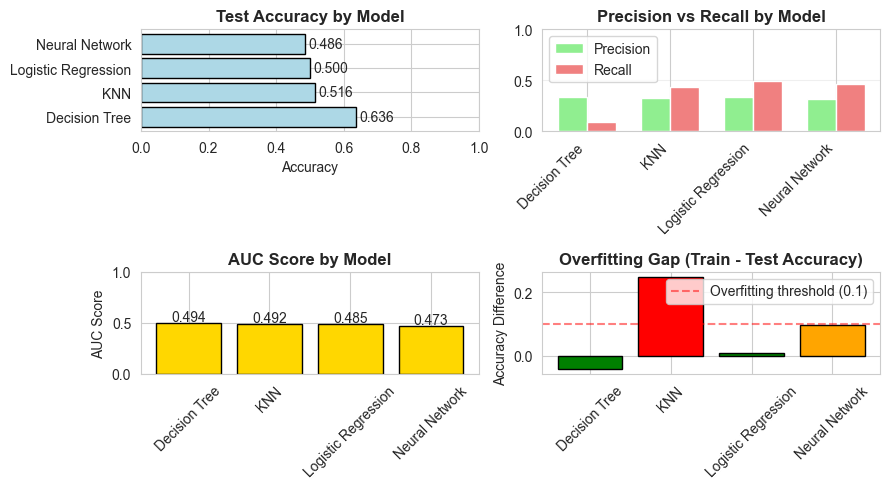

In [52]:
### 7.2 Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(9, 5))

# Test Accuracy Comparison
axes[0, 0].barh(comparison_df['Model'], comparison_df['Test_Accuracy'], color='lightblue', edgecolor='black')
axes[0, 0].set_title('Test Accuracy by Model', fontweight='bold')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(comparison_df['Test_Accuracy']):
    axes[0, 0].text(v + 0.01, i, f'{v:.3f}', va='center')

# Precision-Recall Comparison
x = np.arange(len(comparison_df))
width = 0.35
axes[0, 1].bar(x - width/2, comparison_df['Precision'], width, label='Precision', color='lightgreen')
axes[0, 1].bar(x + width/2, comparison_df['Recall'], width, label='Recall', color='lightcoral')
axes[0, 1].set_title('Precision vs Recall by Model', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# AUC Score Comparison
axes[1, 0].bar(comparison_df['Model'], comparison_df['AUC_Score'], color='gold', edgecolor='black')
axes[1, 0].set_title('AUC Score by Model', fontweight='bold')
axes[1, 0].set_ylabel('AUC Score')
axes[1, 0].set_ylim([0, 1])
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(comparison_df['AUC_Score']):
    axes[1, 0].text(i, v + 0.02, f'{v:.3f}', ha='center')

# Overfitting Gap
colors = ['red' if gap > 0.1 else 'orange' if gap > 0.05 else 'green' for gap in comparison_df['Overfit_Gap']]
axes[1, 1].bar(comparison_df['Model'], comparison_df['Overfit_Gap'], color=colors, edgecolor='black')
axes[1, 1].axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='Overfitting threshold (0.1)')
axes[1, 1].set_title('Overfitting Gap (Train - Test Accuracy)', fontweight='bold')
axes[1, 1].set_ylabel('Accuracy Difference')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### 7.3 Confusion Matrices


Generating Confusion Matrices...


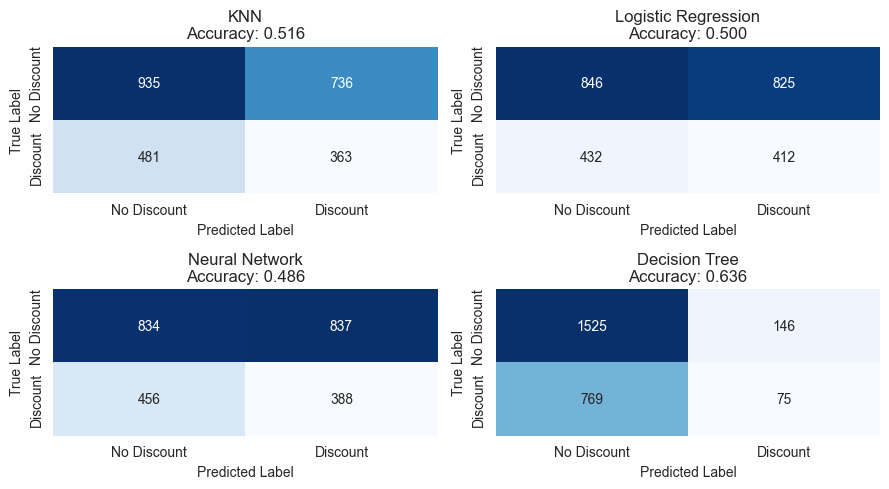

In [53]:
### 7.3 Confusion Matrices
print("\nGenerating Confusion Matrices...")

fig, axes = plt.subplots(2, 2, figsize=(9, 5))
axes = axes.ravel()

models_to_plot = ['KNN', 'Logistic Regression', 'Neural Network', 'Decision Tree']
predictions = {
    'KNN': y_test_pred_knn,
    'Logistic Regression': y_test_pred_lr,
    'Neural Network': y_test_pred_mlp,
    'Decision Tree': y_test_pred_dt
}

for idx, model_name in enumerate(models_to_plot):
    cm = confusion_matrix(y_test_class, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Discount', 'Discount'],
                yticklabels=['No Discount', 'Discount'])
    axes[idx].set_title(f'{model_name}\nAccuracy: {comparison_df[comparison_df["Model"]==model_name]["Test_Accuracy"].values[0]:.3f}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

### 7.4 ROC_curve


Generating ROC Curves...


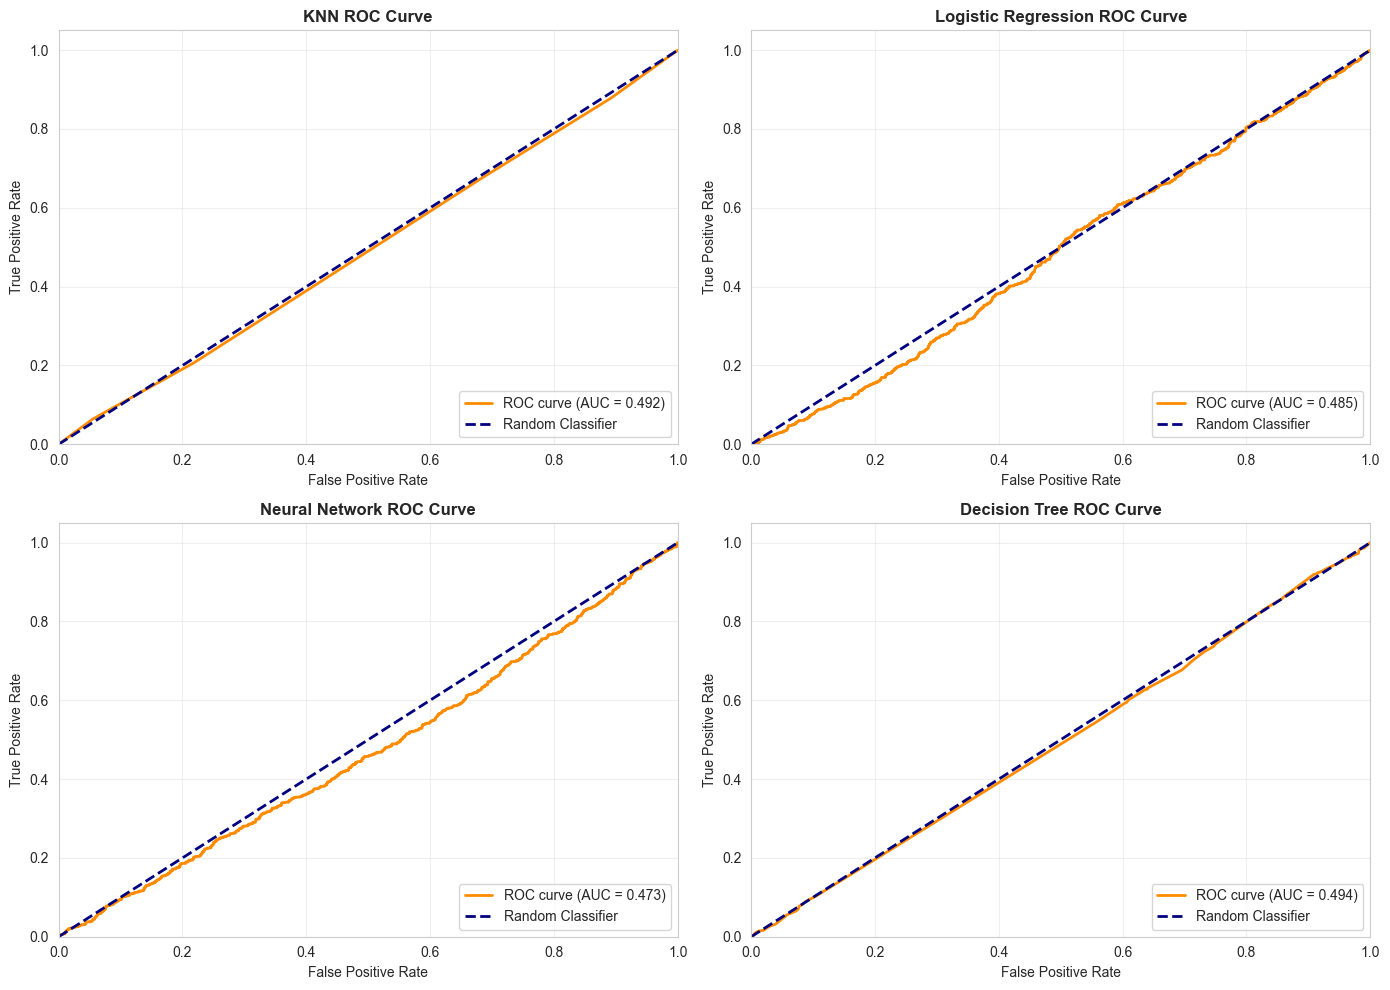

ROC Curves generated successfully!


In [54]:
print("\nGenerating ROC Curves...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

models_roc = ['KNN', 'Logistic Regression', 'Neural Network', 'Decision Tree']
probabilities_dict = {
    'KNN': y_test_pred_knn_proba,
    'Logistic Regression': y_test_pred_lr_proba,
    'Neural Network': y_test_pred_mlp_proba,
    'Decision Tree': y_test_pred_dt_proba
}

for idx, model_name in enumerate(models_roc):
    probabilities = probabilities_dict[model_name]
    fpr, tpr, thresholds = roc_curve(y_test_class, probabilities)
    roc_auc = auc(fpr, tpr)
    
    axes[idx].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    axes[idx].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[idx].set_xlim([0.0, 1.0])
    axes[idx].set_ylim([0.0, 1.05])
    axes[idx].set_xlabel('False Positive Rate')
    axes[idx].set_ylabel('True Positive Rate')
    axes[idx].set_title(f'{model_name} ROC Curve', fontweight='bold')
    axes[idx].legend(loc="lower right")
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("ROC Curves generated successfully!")